In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from sklearn.metrics import r2_score
from scipy.stats import norm
from quantile_forest import RandomForestQuantileRegressor
from src.tqf import trans

# Utility functions

In [2]:
def compute_crps_for_gaussian(y_true, y_mean, y_std) -> float:
    """
    Computes the mean Continuous Ranked Probability Score (CRPS) 
    for Gaussian predictive distributions.
    
    Parameters:
    y_true (1D array): Ground truth values
    y_mean (1D array): Predicted means from GP
    y_std (1D array): Predicted standard deviations from GP
    
    Returns:
    float: The mean CRPS over the entire dataset
    """
    y_true = np.asarray(y_true)
    y_mean = np.asarray(y_mean)
    y_std = np.asarray(y_std)
    
    # Clip standard deviation to a very small positive number to prevent division by zero
    # (This can happen in GP if a test point perfectly overlaps a training point without noise)
    sigma = np.clip(y_std, a_min=1e-9, a_max=None)
    
    # Standardized error (z-score)
    z = (y_true - y_mean) / sigma
    
    # Standard normal PDF and CDF evaluated at z
    pdf_z = norm.pdf(z)
    cdf_z = norm.cdf(z)
    
    # Exact analytical CRPS formula for Gaussian distribution
    crps = sigma * (z * (2 * cdf_z - 1) + 2 * pdf_z - 1 / np.sqrt(np.pi))
    
    # Return the mean CRPS across all test samples
    return np.mean(crps)

In [3]:
def calculate_picp_mpiw_for_gaussian(y_true, y_mean, y_std, conf_levels):
    """
    Compute PICP and MPIW at given confidence levels for a Gaussian predictive distribution
    """
    results = []
    vals = {}
    
    for confidence_level in conf_levels:

        alpha = 1.0 - confidence_level
        lower_q = alpha / 2.0
        upper_q = 1.0 - (alpha / 2.0)
        
        z_score = norm.ppf(upper_q)
        y_lower = y_mean - z_score * y_std
        y_upper = y_mean + z_score * y_std
        
        # PICP
        is_covered = (y_lower <= y_true) & (y_true <= y_upper)
        picp = np.mean(is_covered)
        
        # MPIW
        mpiw = np.mean(y_upper - y_lower)
        
        results.append({
            'Nominal_Confidence_Level': round(confidence_level, 2),
            'Lower_Quantile': round(lower_q, 3),
            'Upper_Quantile': round(upper_q, 3),
            'PICP': picp,
            'MPIW': mpiw
        })

        vals[round(confidence_level, 2)] = (y_lower, y_upper)
        
    return pd.DataFrame(results), vals

In [4]:
def compute_empirical_crps(y_true, y_pred) -> float:
    """
    Fast approximation of CRPS using equally spaced (and sorted) quantiles.
    y_true: Ground truth data of shape (N,)
    y_pred: Quantile predictions of shape (N, M)
    """
    assert np.all(np.diff(y_pred, axis=1) >= 0.), \
        "Error: The quantiles in y_pred must be sorted in ascending order along axis=1."
    y_true = np.asarray(y_true).reshape(-1, 1)
    M = y_pred.shape[1]
    
    # Term 1: Mean absolute error between true values and each quantile prediction
    term1 = np.mean(np.abs(y_pred - y_true), axis=1)
    
    # Term 2: Expected absolute difference between quantiles 
    # (Computationally optimized by leveraging the fact that quantiles are already sorted)
    weights = np.arange(M) * 2 - M + 1
    term2 = np.sum(y_pred * weights, axis=1) / (M ** 2)
    
    # Calculate CRPS for each sample
    crps = term1 - term2
    return np.mean(crps)

In [5]:
def calculate_picp_mpiw_for_qrf(regressor, X_test, y_true, conf_levels):
    """
    Compute PICP and MPIW at given confidence levels directly using a QRF model.
    """
    results = []
    vals = {}
    
    # 1. Calculate all required quantiles, remove duplicates, and sort them
    required_quantiles = []
    for confidence_level in conf_levels:
        alpha = 1.0 - confidence_level
        # Round to 4 decimal places to prevent dictionary key errors due to floating-point inaccuracies
        required_quantiles.extend([round(alpha / 2.0, 4), round(1.0 - (alpha / 2.0), 4)])
        
    required_quantiles = sorted(list(set(required_quantiles)))
    
    # 2. Predict all quantiles at once using the QRF model (execute predict only once for efficiency)
    # The shape of the output y_pred_all will be (n_samples, len(required_quantiles))
    y_pred_all = regressor.predict(X=X_test, quantiles=required_quantiles)
    
    # Create a dictionary with quantiles as keys and 1D arrays of predictions (n_samples,) as values
    pred_dict = {q: y_pred_all[:, i] for i, q in enumerate(required_quantiles)}
    
    # 3. Calculate metrics for each confidence level
    for confidence_level in conf_levels:
        
        alpha = 1.0 - confidence_level
        lower_q = round(alpha / 2.0, 4)
        upper_q = round(1.0 - (alpha / 2.0), 4)
        
        # Retrieve the lower and upper bound arrays from the dictionary
        y_lower = pred_dict[lower_q]
        y_upper = pred_dict[upper_q]
        
        # PICP (Prediction Interval Coverage Probability)
        is_covered = (y_lower <= y_true) & (y_true <= y_upper)
        picp = np.mean(is_covered)
        
        # MPIW (Mean Prediction Interval Width)
        mpiw = np.mean(y_upper - y_lower)
        
        results.append({
            'Nominal_Confidence_Level': round(confidence_level, 2),
            'Lower_Quantile': lower_q,
            'Upper_Quantile': upper_q,
            'PICP': picp,
            'MPIW': mpiw
        })

        vals[round(confidence_level, 2)] = (y_lower, y_upper)
        
    return pd.DataFrame(results), vals

In [6]:
def calculate_picp_mpiw_for_qrfpp(regressor, X_test, y_true, conf_levels):
    """
    Compute PICP and MPIW at given confidence levels directly using a QRF++ model.
    """
    results = []
    vals = {}
    
    # 1. Calculate all required quantiles, remove duplicates, and sort them
    required_quantiles = []
    for confidence_level in conf_levels:
        alpha = 1.0 - confidence_level
        # Round to 4 decimal places to prevent dictionary key errors due to floating-point inaccuracies
        required_quantiles.extend([round(alpha / 2.0, 4), round(1.0 - (alpha / 2.0), 4)])
        
    required_quantiles = sorted(list(set(required_quantiles)))
    
    # 2. Predict all quantiles at once using the QRF model (execute predict only once for efficiency)
    # The shape of the output y_pred_all will be (n_samples, len(required_quantiles))
    y_pred_all = regressor.predict(X=X_test, quantiles=required_quantiles)[:, 0, :]
    
    # Create a dictionary with quantiles as keys and 1D arrays of predictions (n_samples,) as values
    pred_dict = {q: y_pred_all[:, i] for i, q in enumerate(required_quantiles)}
    
    # 3. Calculate metrics for each confidence level
    for confidence_level in conf_levels:
        
        alpha = 1.0 - confidence_level
        lower_q = round(alpha / 2.0, 4)
        upper_q = round(1.0 - (alpha / 2.0), 4)
        
        # Retrieve the lower and upper bound arrays from the dictionary
        y_lower = pred_dict[lower_q]
        y_upper = pred_dict[upper_q]
        
        # PICP (Prediction Interval Coverage Probability)
        is_covered = (y_lower <= y_true) & (y_true <= y_upper)
        picp = np.mean(is_covered)
        
        # MPIW (Mean Prediction Interval Width)
        mpiw = np.mean(y_upper - y_lower)
        
        results.append({
            'Nominal_Confidence_Level': round(confidence_level, 2),
            'Lower_Quantile': lower_q,
            'Upper_Quantile': upper_q,
            'PICP': picp,
            'MPIW': mpiw
        })

        vals[round(confidence_level, 2)] = (y_lower, y_upper)
        
    return pd.DataFrame(results), vals

In [7]:
def show_result_of_all_runs(out):
    
    print(r"- R^2 : {:.6f} ± {:.6f}".format(np.mean(out[0]), np.std(out[0])))
    print(r"- CRPS : {:.6f} ± {:.6f}".format(np.mean(out[1]), np.std(out[1])))
    conf = out[2][0]['Nominal_Confidence_Level'].values
    print("- Confidence levels:", conf)
    p_mean = np.c_[[table['PICP'].values for table in out[2]]].mean(axis=0)
    p_std = np.c_[[table['PICP'].values for table in out[2]]].std(axis=0)
    print("- PICP (mean):\n", p_mean)
    print("- PICP (std):\n", p_std)
    m_mean = np.c_[[table['MPIW'].values for table in out[2]]].mean(axis=0)
    m_std = np.c_[[table['MPIW'].values for table in out[2]]].std(axis=0)
    print("- MPIW (mean):\n", m_mean)
    print("- MPIW (std):\n", m_std)
    assert len(p_mean) == len(p_std) == len(m_mean) == len(m_std) == len(conf)

    # ---------------------------------------------------------
    # Plotting
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # --- Plot 1: PICP (Calibration Curve) ---
    axes[0].errorbar(conf, p_mean, yerr=p_std, fmt='o-', capsize=4, color='blue', label='Model PICP')
    # Add a diagonal line（Oracle Coverage）
    axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--', label='Oracle Coverage')
    
    axes[0].set_xlabel('Nominal Confidence Level')
    axes[0].set_ylabel('PICP (Empirical Coverage)')
    axes[0].set_title('Calibration Curve')
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_box_aspect(1)

    # --- Plot 2: MPIW (Sharpness) ---
    axes[1].errorbar(conf, m_mean, yerr=m_std, fmt='s-', capsize=4, color='orange', label='Model MPIW')
    
    axes[1].set_xlabel('Nominal Confidence Level')
    axes[1].set_ylabel('MPIW (Interval Width)')
    axes[1].set_title('Prediction Interval Width')
    axes[1].set_xlim([0, 1])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_box_aspect(1)

    plt.tight_layout()
    plt.show()

# Load Dataset

In [8]:
df = pd.read_csv("datasets/Concrete_Data.csv")
df = df.drop_duplicates()
y = df[df.columns[-1]].values
X = df[df.columns[:-1]].values
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)
y = StandardScaler().fit_transform(y.reshape(-1, 1)).ravel()
from sklearn.model_selection import train_test_split

def splitter(X, y, seed: int, valid_ratio: float = 0.1, test_ratio: float = 0.1):

    assert valid_ratio + test_ratio < 1.0
    assert valid_ratio >= 0.0 and test_ratio > 0.0
    X_o, X_test, y_o, y_test = train_test_split(X, y, random_state=seed, test_size=test_ratio)
    if valid_ratio == 0.:
        X_train, X_valid, y_train, y_valid = X_o, None, y_o, None
    else:
        X_train, X_valid, y_train, y_valid \
            = train_test_split(X_o, y_o, random_state=seed,
                               test_size=valid_ratio / (1 - test_ratio))

    return (X_train, y_train), (X_valid, y_valid), (X_test, y_test)

# Gaussian Process Regression

## Single run (GP)

In [90]:
seed = 1000

In [91]:
res = splitter(X, y, seed=seed, valid_ratio=0., test_ratio=0.1)

In [11]:
for i in range(3):
    try:
        print(i, res[i][0].shape, res[i][1].shape)
    except:
        pass

0 (904, 8) (904,)
2 (101, 8) (101,)


In [ ]:
%%time
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
gp = GaussianProcessRegressor(random_state=seed, kernel=ConstantKernel() * Matern([1.] * X.shape[1]) + WhiteKernel())
gp.fit(res[0][0], res[0][1])

CPU times: total: 25.4 s
Wall time: 7.44 s


,kernel,1**2 * Matern...noise_level=1)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,1000
,kernel__k1,"1**2 * Matern...1, 1], nu=1.5)"
,kernel__k2,WhiteKernel(noise_level=1)
,kernel__k1__k1,1**2


In [14]:
gp.kernel_

2.91**2 * Matern(length_scale=[14.9, 19.1, 15.7, 5.15, 8.84, 5.49, 3.72, 2.41], nu=1.5) + WhiteKernel(noise_level=0.0406)

In [15]:
y_pred, y_std = gp.predict(res[2][0], return_std=True)

R^2: 0.9508494306227735
CRPS: 0.12510772117603366


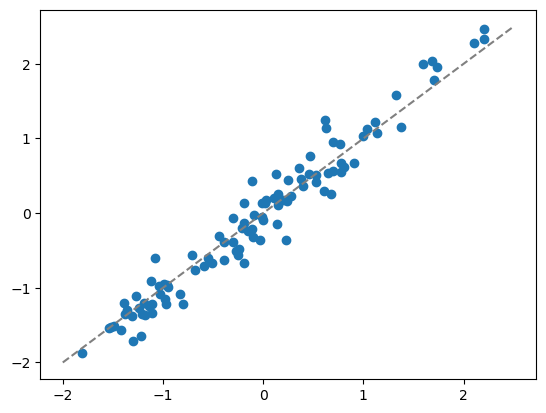

In [16]:
print("R^2:", r2_score(y_true=res[2][1], y_pred=gp.predict(res[2][0])))
print("CRPS:", compute_crps_for_gaussian(y_true=res[2][1], y_mean=y_pred, y_std=y_std))
plt.scatter(gp.predict(res[2][0]), res[2][1])
plt.plot([-2, 2.5], [-2, 2.5], c='grey', ls='--')

In [17]:
# generate 19 confidence levels from 0.05 to 0.95 with 0.05 step size
confidence_levels = np.arange(0.05, 0.96, 0.05)
df_metrics, vals = calculate_picp_mpiw_for_gaussian(res[2][1], y_pred, y_std, confidence_levels)

print("=== PICP and MPIW Evaluation ===")
print(df_metrics.to_string(index=False))

=== PICP and MPIW Evaluation ===
 Nominal_Confidence_Level  Lower_Quantile  Upper_Quantile     PICP     MPIW
                     0.05           0.475           0.525 0.059406 0.032982
                     0.10           0.450           0.550 0.108911 0.066095
                     0.15           0.425           0.575 0.178218 0.099472
                     0.20           0.400           0.600 0.217822 0.133255
                     0.25           0.375           0.625 0.306931 0.167598
                     0.30           0.350           0.650 0.386139 0.202670
                     0.35           0.325           0.675 0.465347 0.238669
                     0.40           0.300           0.700 0.504950 0.275824
                     0.45           0.275           0.725 0.534653 0.314409
                     0.50           0.250           0.750 0.623762 0.354767
                     0.55           0.225           0.775 0.653465 0.397332
                     0.60           0.200           0.8

<Axes: xlabel='Nominal_Confidence_Level', ylabel='PICP'>

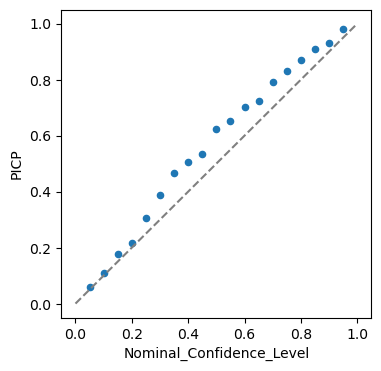

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 1], [0, 1], c='grey', ls='--')
df_metrics.plot(kind='scatter', x='Nominal_Confidence_Level', y='PICP', ax=ax)

<Axes: xlabel='Nominal_Confidence_Level', ylabel='MPIW'>

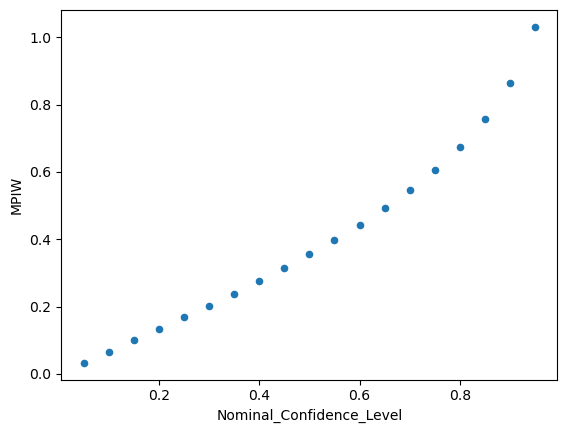

In [19]:
df_metrics.plot(kind='scatter', x='Nominal_Confidence_Level', y='MPIW')

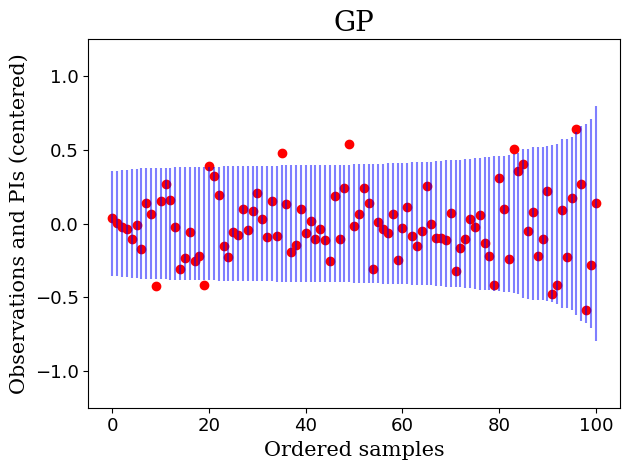

In [ ]:
confidence = 0.90
bounds = vals[confidence]
y_center = (bounds[0] + bounds[1]) / 2

idx_sorted = np.argsort(bounds[1] - bounds[0])
plt.vlines(x=range(len(res[2][1])), ymin=(bounds[0] - y_center)[idx_sorted], 
           ymax=(bounds[1] - y_center)[idx_sorted], 
           colors='blue', alpha=0.5, label='Multiple Lines')
plt.scatter(x=range(len(res[2][1])), y=(res[2][1] - y_center)[idx_sorted], c='r')
plt.ylim(-1.25, 1.25)
plt.xlabel('Ordered samples', fontsize=15, fontname='serif')
plt.ylabel('Observations and PIs (centered)', fontsize=15, fontname='serif')
plt.title("GP", fontsize=20, fontname='serif')
plt.tick_params(labelsize=13)
plt.tight_layout()
# plt.savefig('fg_ordered_PI_GP.pdf', dpi=400)

## Repeated run (GP)

In [23]:
def repeat_gp(N_rep: int):

    kekka_R2 = []
    kekka_CRPS = []
    kekka_PI = []

    for seed in range(N_rep):

        res = splitter(X, y, seed=seed, valid_ratio=0., test_ratio=0.1)

        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
        gp = GaussianProcessRegressor(random_state=seed, kernel=ConstantKernel() * Matern([1.] * X.shape[1]) + WhiteKernel())
        gp.fit(res[0][0], res[0][1])
        y_pred, y_std = gp.predict(res[2][0], return_std=True)
        kekka_R2.append(r2_score(y_true=res[2][1], y_pred=y_pred))
        kekka_CRPS.append(compute_crps_for_gaussian(y_true=res[2][1], y_mean=y_pred, y_std=y_std))

        confidence_levels = np.arange(0.05, 0.96, 0.05)
        df_metrics, _ = calculate_picp_mpiw_for_gaussian(y_true=res[2][1], y_mean=y_pred, 
                                                         y_std=y_std, conf_levels=confidence_levels)
        kekka_PI.append(df_metrics)

    return kekka_R2, kekka_CRPS, kekka_PI

In [24]:
%%time
out_gp = repeat_gp(20)

CPU times: total: 9min 42s
Wall time: 2min 49s


- R^2 : 0.916197 ± 0.027314
- CRPS : 0.145890 ± 0.018238
- Confidence levels: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
- PICP (mean):
 [0.08514851 0.16584158 0.22178218 0.28267327 0.34455446 0.42029703
 0.47772277 0.53762376 0.59059406 0.63663366 0.67772277 0.70841584
 0.74306931 0.77376238 0.80891089 0.8470297  0.86881188 0.89752475
 0.92920792]
- PICP (std):
 [0.03304618 0.04044588 0.03877853 0.04595969 0.04299812 0.03450818
 0.03676388 0.03924341 0.03654994 0.03986301 0.03091187 0.03521121
 0.0347911  0.0373459  0.0388669  0.03776355 0.03729336 0.04145134
 0.03760747]
- MPIW (mean):
 [0.03307784 0.06628638 0.09976    0.13364064 0.16808232 0.20325661
 0.23935963 0.27662136 0.31531857 0.35579346 0.39848155 0.44395534
 0.49299601 0.54671879 0.60680949 0.67601866 0.75935309 0.86766056
 1.03388133]
- MPIW (std):
 [0.00105441 0.00211298 0.00318    0.00426    0.00535788 0.00647911
 0.00762995 0.00881772 0.01005126 0.01134145 0.0127022

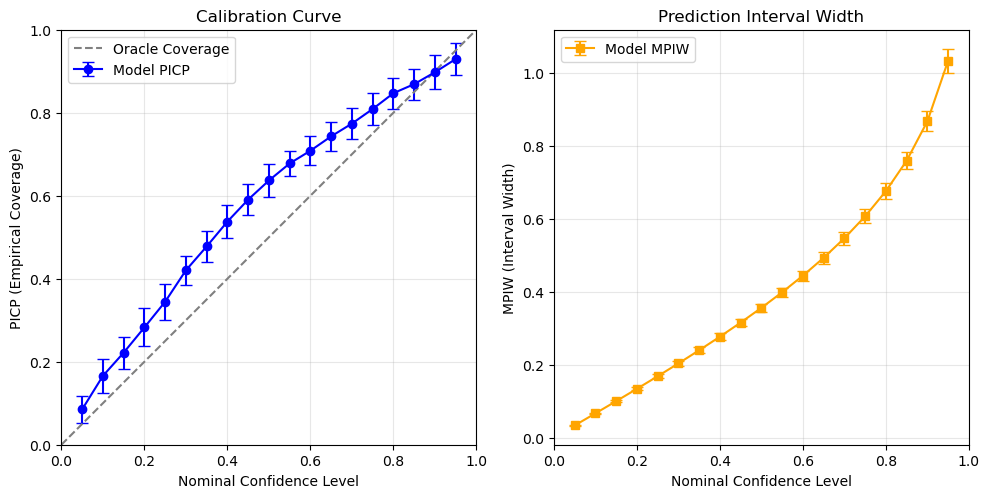

In [25]:
show_result_of_all_runs(out_gp)

# QRF

## Single run (QRF)

In [71]:
seed = 1000

In [72]:
res = splitter(X, y, seed=seed, valid_ratio=0.1, test_ratio=0.1)

In [73]:
for i in range(3):
    try:
        print(i, res[i][0].shape, res[i][1].shape)
    except:
        pass

0 (803, 8) (803,)
1 (101, 8) (101,)
2 (101, 8) (101,)


In [75]:
qrf = RandomForestQuantileRegressor(random_state=seed, n_estimators=300, n_jobs=3,
                                    max_samples_leaf=None, max_leaf_nodes=None)
qrf.fit(np.r_[res[0][0], res[1][0]], np.r_[res[0][1], res[1][1]])
np.array([tree.get_n_leaves() for tree in qrf.estimators_])

array([550, 559, 543, 544, 525, 543, 525, 562, 527, 557, 544, 552, 550,
       567, 530, 542, 561, 542, 543, 558, 547, 531, 550, 559, 532, 544,
       545, 543, 545, 552, 540, 550, 550, 529, 557, 541, 553, 530, 546,
       535, 548, 562, 545, 542, 551, 539, 540, 553, 546, 557, 550, 542,
       549, 532, 554, 534, 529, 539, 546, 543, 539, 541, 555, 556, 545,
       557, 544, 549, 543, 548, 555, 546, 551, 547, 534, 551, 545, 558,
       551, 550, 544, 550, 565, 546, 554, 560, 535, 537, 545, 557, 529,
       548, 531, 537, 538, 536, 545, 539, 550, 545, 548, 543, 556, 544,
       548, 555, 550, 544, 545, 533, 535, 552, 549, 541, 553, 559, 546,
       544, 536, 540, 564, 545, 550, 560, 541, 539, 537, 538, 539, 558,
       547, 551, 539, 567, 552, 535, 558, 541, 524, 542, 539, 560, 556,
       554, 536, 539, 554, 551, 543, 543, 552, 557, 548, 556, 554, 549,
       559, 545, 556, 541, 551, 537, 560, 542, 550, 545, 538, 551, 545,
       546, 537, 534, 550, 538, 552, 538, 549, 536, 555, 544, 55

R^2: 0.9441363373422673
CRPS: 0.1386516727053207


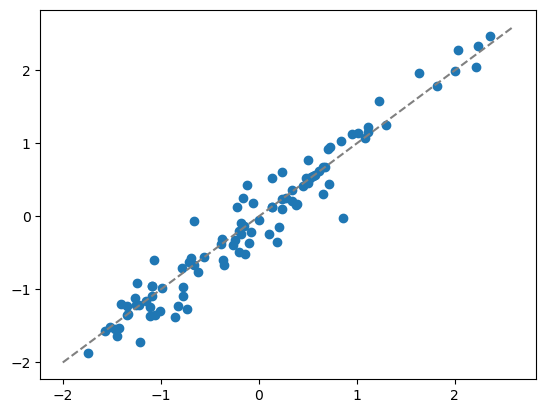

In [30]:
qrf = RandomForestQuantileRegressor(random_state=seed, n_estimators=300, n_jobs=3,
                                    max_samples_leaf=None, max_leaf_nodes=None)
qrf.fit(np.r_[res[0][0], res[1][0]], np.r_[res[0][1], res[1][1]])

print("R^2:", r2_score(y_true=res[2][1], y_pred=qrf.predict(res[2][0], quantiles='mean')))
print("CRPS:", compute_empirical_crps(y_true=res[2][1], 
                                      y_pred=qrf.predict(res[2][0], quantiles=list(np.linspace(0.01, 0.99, 99)))))
plt.scatter(qrf.predict(res[2][0]), res[2][1])
plt.plot([-2, 2.6], [-2, 2.6], c='grey', ls='--')

In [31]:
# generate 19 confidence levels from 0.05 to 0.95 with 0.05 step size
confidence_levels = np.arange(0.05, 0.96, 0.05)
df_metrics, vals = calculate_picp_mpiw_for_qrf(regressor=qrf, X_test=res[2][0], 
                                               y_true=res[2][1], conf_levels=confidence_levels)
print("=== PICP and MPIW Evaluation ===")
print(df_metrics.to_string(index=False))

=== PICP and MPIW Evaluation ===
 Nominal_Confidence_Level  Lower_Quantile  Upper_Quantile     PICP     MPIW
                     0.05           0.475           0.525 0.207921 0.033782
                     0.10           0.450           0.550 0.227723 0.070016
                     0.15           0.425           0.575 0.257426 0.095835
                     0.20           0.400           0.600 0.277228 0.126134
                     0.25           0.375           0.625 0.297030 0.149715
                     0.30           0.350           0.650 0.326733 0.177654
                     0.35           0.325           0.675 0.386139 0.212435
                     0.40           0.300           0.700 0.435644 0.249375
                     0.45           0.275           0.725 0.475248 0.281585
                     0.50           0.250           0.750 0.504950 0.315887
                     0.55           0.225           0.775 0.544554 0.360958
                     0.60           0.200           0.8

<Axes: xlabel='Nominal_Confidence_Level', ylabel='PICP'>

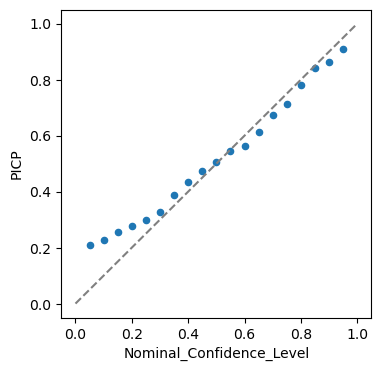

In [32]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 1], [0, 1], c='grey', ls='--')
df_metrics.plot(kind='scatter', x='Nominal_Confidence_Level', y='PICP', ax=ax)

<Axes: xlabel='Nominal_Confidence_Level', ylabel='MPIW'>

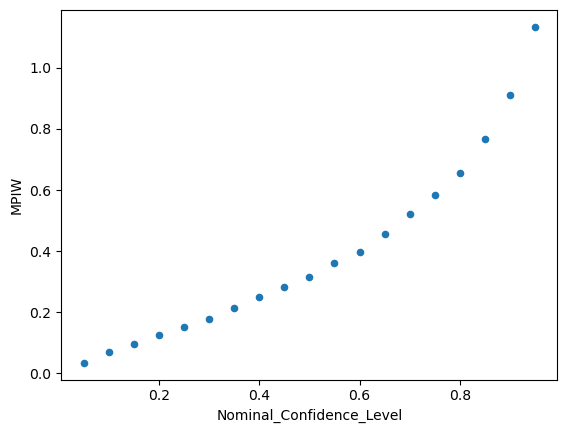

In [33]:
df_metrics.plot(kind='scatter', x='Nominal_Confidence_Level', y='MPIW')

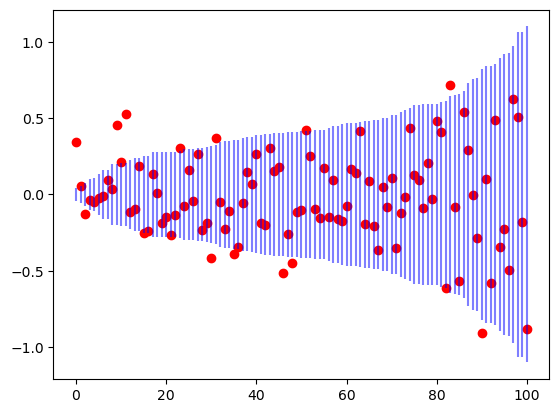

In [34]:
confidence = 0.90
bounds = vals[confidence]
y_center = (bounds[0] + bounds[1]) / 2

idx_sorted = np.argsort(bounds[1] - bounds[0])
plt.vlines(x=range(len(res[2][1])), ymin=(bounds[0] - y_center)[idx_sorted], 
           ymax=(bounds[1] - y_center)[idx_sorted], 
           colors='blue', alpha=0.5, label='Multiple Lines')
plt.scatter(x=range(len(res[2][1])), y=(res[2][1] - y_center)[idx_sorted], c='r')

## Repeated run (QRF)

In [36]:
def repeat_qrf(N_rep: int):

    kekka_R2 = []
    kekka_CRPS = []
    kekka_PI = []

    for seed in range(N_rep):

        res = splitter(X, y, seed=seed, valid_ratio=0.1, test_ratio=0.1)
        qrf = RandomForestQuantileRegressor(random_state=seed, n_estimators=300, n_jobs=3,
                                            max_samples_leaf=None, max_leaf_nodes=None)
        qrf.fit(np.r_[res[0][0], res[1][0]], np.r_[res[0][1], res[1][1]])

        y_pred = qrf.predict(res[2][0], quantiles='mean')
        y_pred_q = qrf.predict(res[2][0], quantiles=list(np.linspace(0.01, 0.99, 99)))
        
        kekka_R2.append(r2_score(y_true=res[2][1], y_pred=y_pred))
        kekka_CRPS.append(compute_empirical_crps(y_true=res[2][1], y_pred=y_pred_q))
        confidence_levels = np.arange(0.05, 0.96, 0.05)
        df_metrics, _ = calculate_picp_mpiw_for_qrf(regressor=qrf, X_test=res[2][0], 
                                                    y_true=res[2][1], conf_levels=confidence_levels)
        kekka_PI.append(df_metrics)

    return kekka_R2, kekka_CRPS, kekka_PI

In [37]:
%%time
out_qrf = repeat_qrf(20)

CPU times: total: 35.2 s
Wall time: 18.5 s


- R^2 : 0.900281 ± 0.026732
- CRPS : 0.158365 ± 0.016744
- Confidence levels: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
- PICP (mean):
 [0.16534653 0.21336634 0.2549505  0.29356436 0.33168317 0.37326733
 0.41584158 0.45693069 0.50247525 0.54257426 0.58811881 0.62772277
 0.66237624 0.70594059 0.74653465 0.78366337 0.83217822 0.86980198
 0.92128713]
- PICP (std):
 [0.03652647 0.0434376  0.05475838 0.05389223 0.05271754 0.05531278
 0.06787777 0.06426307 0.05564629 0.05744281 0.05910816 0.05507301
 0.04949505 0.04362058 0.04541523 0.04296106 0.04206173 0.03654994
 0.03710891]
- MPIW (mean):
 [0.02879867 0.06056774 0.0931548  0.12593137 0.15977925 0.19516347
 0.23300462 0.27266014 0.31650862 0.3597329  0.40782416 0.45815784
 0.51757348 0.58218685 0.65060059 0.73810422 0.84537096 0.99443495
 1.23058254]
- MPIW (std):
 [0.00724048 0.0136474  0.01986402 0.0190256  0.02099521 0.02154356
 0.02210391 0.02476329 0.02738283 0.02587671 0.0261531

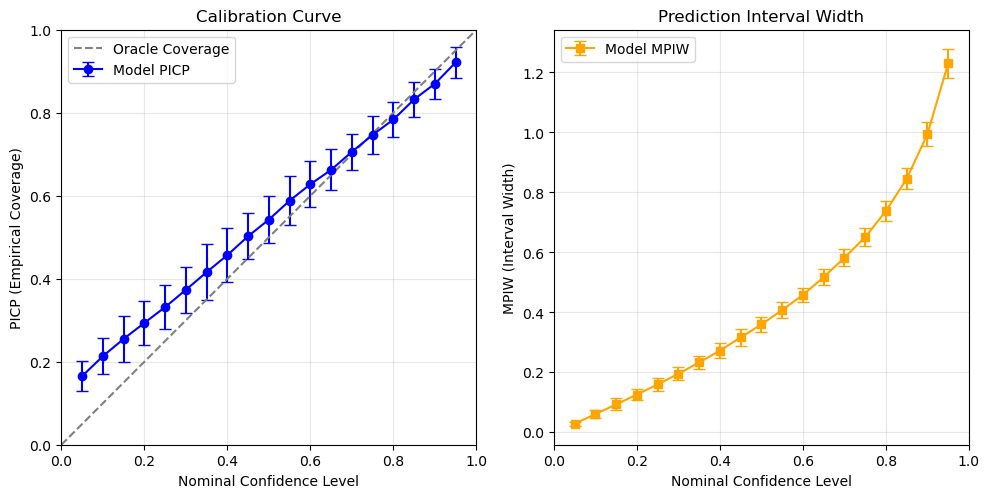

In [78]:
show_result_of_all_runs(out_qrf)

# QRF++

## Single run (QRF++)

In [79]:
t_rff = 'median'

In [80]:
seed = 1000

In [81]:
res = splitter(X, y, seed=seed, valid_ratio=0.1, test_ratio=0.1)

In [82]:
for i in range(3):
    try:
        print(i, res[i][0].shape, res[i][1].shape)
    except:
        pass

0 (803, 8) (803,)
1 (101, 8) (101,)
2 (101, 8) (101,)


R^2: 0.9476987029719837
CRPS: 0.13332572534627327


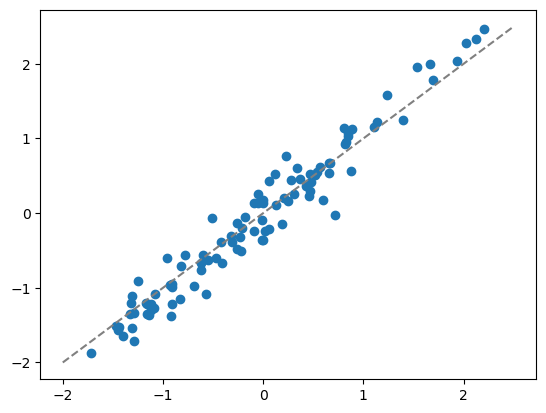

In [83]:
qrfpp = RandomForestQuantileRegressor(random_state=seed, n_estimators=300, n_jobs=3,
                                      max_samples_leaf=None, max_leaf_nodes=None)
_, ys_big = trans(np.r_[res[0][1], res[1][1]], seed=seed, T_rff=t_rff)
qrfpp.fit(np.r_[res[0][0], res[1][0]], ys_big)

print("R^2:", r2_score(y_true=res[2][1], y_pred=qrfpp.predict(res[2][0], quantiles='mean')[:, 0]))
print("CRPS:", compute_empirical_crps(y_true=res[2][1], 
                                      y_pred=qrfpp.predict(res[2][0], quantiles=list(np.linspace(0.01, 0.99, 99)))[:, 0, :]))
plt.scatter(qrfpp.predict(res[2][0], quantiles='mean')[:, 0], res[2][1])
plt.plot([-2, 2.5], [-2, 2.5], c='grey', ls='--')

In [84]:
np.array([tree.get_n_leaves() for tree in qrfpp.estimators_])

array([561, 568, 550, 554, 534, 552, 528, 567, 535, 568, 551, 563, 560,
       573, 538, 552, 569, 552, 553, 569, 561, 539, 561, 569, 537, 552,
       553, 542, 553, 562, 549, 555, 563, 535, 564, 552, 561, 538, 558,
       544, 559, 571, 554, 553, 558, 545, 544, 559, 558, 563, 558, 551,
       560, 540, 561, 543, 533, 545, 561, 552, 547, 546, 560, 560, 556,
       569, 552, 557, 548, 556, 562, 553, 560, 555, 544, 558, 555, 562,
       558, 551, 553, 557, 575, 554, 559, 571, 549, 547, 554, 568, 535,
       556, 541, 547, 545, 543, 550, 548, 557, 555, 555, 549, 561, 556,
       556, 565, 558, 551, 552, 536, 538, 556, 560, 552, 567, 574, 553,
       550, 545, 553, 571, 556, 555, 572, 548, 545, 547, 548, 541, 566,
       555, 559, 553, 574, 565, 541, 560, 556, 535, 548, 548, 568, 565,
       562, 543, 546, 559, 563, 544, 551, 561, 566, 556, 570, 563, 555,
       564, 553, 569, 544, 562, 544, 570, 549, 557, 556, 547, 561, 554,
       560, 542, 545, 559, 541, 561, 546, 560, 545, 566, 550, 56

In [85]:
# generate 19 confidence levels from 0.05 to 0.95 with 0.05 step size
confidence_levels = np.arange(0.05, 0.96, 0.05)
df_metrics, vals = calculate_picp_mpiw_for_qrfpp(regressor=qrfpp, X_test=res[2][0], 
                                                 y_true=res[2][1], conf_levels=confidence_levels)
print("=== PICP and MPIW Evaluation ===")
print(df_metrics.to_string(index=False))

=== PICP and MPIW Evaluation ===
 Nominal_Confidence_Level  Lower_Quantile  Upper_Quantile     PICP     MPIW
                     0.05           0.475           0.525 0.188119 0.027722
                     0.10           0.450           0.550 0.257426 0.069403
                     0.15           0.425           0.575 0.267327 0.101154
                     0.20           0.400           0.600 0.297030 0.130674
                     0.25           0.375           0.625 0.326733 0.156473
                     0.30           0.350           0.650 0.346535 0.183613
                     0.35           0.325           0.675 0.396040 0.218580
                     0.40           0.300           0.700 0.425743 0.253251
                     0.45           0.275           0.725 0.485149 0.286998
                     0.50           0.250           0.750 0.495050 0.321342
                     0.55           0.225           0.775 0.534653 0.368576
                     0.60           0.200           0.8

<Axes: xlabel='Nominal_Confidence_Level', ylabel='PICP'>

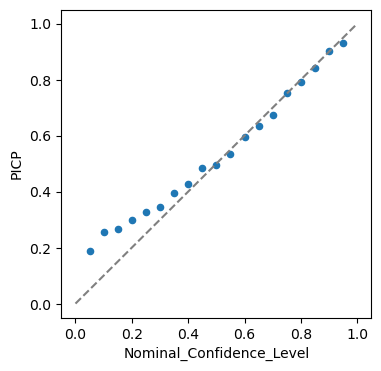

In [86]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 1], [0, 1], c='grey', ls='--')
df_metrics.plot(kind='scatter', x='Nominal_Confidence_Level', y='PICP', ax=ax)

<Axes: xlabel='Nominal_Confidence_Level', ylabel='MPIW'>

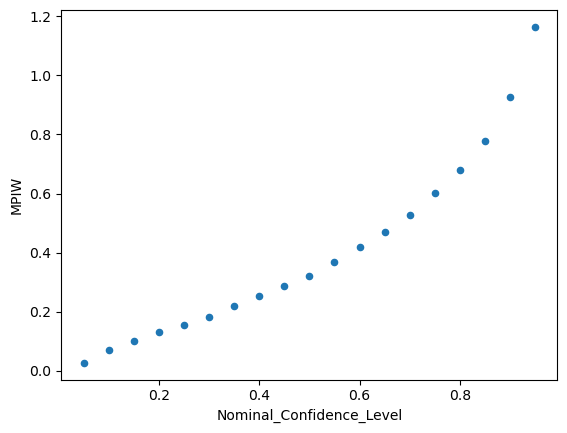

In [87]:
df_metrics.plot(kind='scatter', x='Nominal_Confidence_Level', y='MPIW')

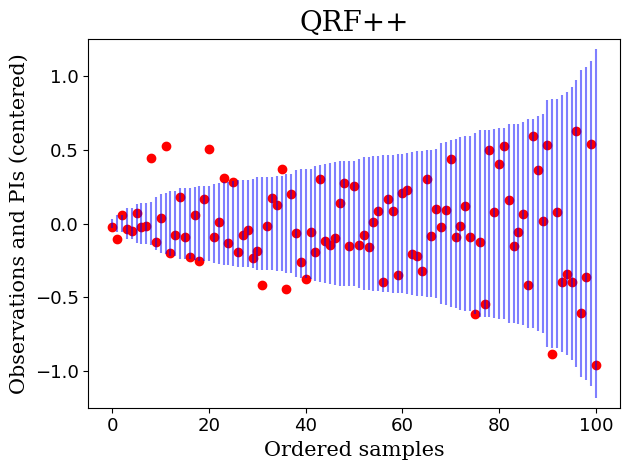

In [ ]:
confidence = 0.90
bounds = vals[confidence]
y_center = (bounds[0] + bounds[1]) / 2

idx_sorted = np.argsort(bounds[1] - bounds[0])
plt.vlines(x=range(len(res[2][1])), ymin=(bounds[0] - y_center)[idx_sorted], 
           ymax=(bounds[1] - y_center)[idx_sorted], 
           colors='blue', alpha=0.5, label='Multiple Lines')
plt.scatter(x=range(len(res[2][1])), y=(res[2][1] - y_center)[idx_sorted], c='r')
plt.ylim(-1.25, 1.25)
plt.xlabel('Ordered samples', fontsize=15, fontname='serif')
plt.ylabel('Observations and PIs (centered)', fontsize=15, fontname='serif')
plt.title("QRF++", fontsize=20, fontname='serif')
plt.tick_params(labelsize=13)
plt.tight_layout()
# plt.savefig('fg_ordered_PI_QRF++_(#leaves=None).pdf', dpi=400)

## Repeated run (QRF++)

In [ ]:
def repeat_qrfpp(N_rep: int, max_leaf_nodes: int):

    kekka_R2 = []
    kekka_CRPS = []
    kekka_PI = []

    for seed in range(N_rep):

        res = splitter(X, y, seed=seed, valid_ratio=0.1, test_ratio=0.1)
        qrfpp = RandomForestQuantileRegressor(random_state=seed, n_estimators=300, n_jobs=3,
                                              max_samples_leaf=None, max_leaf_nodes=max_leaf_nodes)
        _, ys_big = trans(np.r_[res[0][1], res[1][1]], seed=seed, T_rff=t_rff)
        qrfpp.fit(np.r_[res[0][0], res[1][0]], ys_big)

        y_pred = qrfpp.predict(res[2][0], quantiles='mean')[:, 0]
        y_pred_q = qrfpp.predict(res[2][0], quantiles=list(np.linspace(0.01, 0.99, 99)))[:, 0, :]
        
        kekka_R2.append(r2_score(y_true=res[2][1], y_pred=y_pred))
        kekka_CRPS.append(compute_empirical_crps(y_true=res[2][1], y_pred=y_pred_q))
        confidence_levels = np.arange(0.05, 0.96, 0.05)
        df_metrics, _ = calculate_picp_mpiw_for_qrfpp(regressor=qrfpp, X_test=res[2][0], 
                                                      y_true=res[2][1], conf_levels=confidence_levels)
        kekka_PI.append(df_metrics)

    return kekka_R2, kekka_CRPS, kekka_PI

### max_leaf_nodes = 500

In [93]:
%%time
out_qrfpp_1 = repeat_qrfpp(N_rep=20, max_leaf_nodes=500)

CPU times: total: 47.6 s
Wall time: 25.4 s


- R^2 : 0.901374 ± 0.026590
- CRPS : 0.158729 ± 0.017052
- Confidence levels: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
- PICP (mean):
 [0.1519802  0.1980198  0.2460396  0.29752475 0.34059406 0.37722772
 0.41138614 0.4509901  0.4960396  0.53960396 0.57970297 0.62574257
 0.66732673 0.71039604 0.7549505  0.79851485 0.83712871 0.87673267
 0.92277228]
- PICP (std):
 [0.03573627 0.03860117 0.04593835 0.05014194 0.06465278 0.06844585
 0.06733219 0.06630522 0.0617444  0.0651136  0.06131224 0.04866616
 0.04563057 0.04642657 0.04589565 0.05022008 0.04905488 0.03617251
 0.03409738]
- MPIW (mean):
 [0.03197931 0.06378546 0.09763769 0.13412834 0.16771209 0.20083146
 0.23559017 0.27195081 0.31175003 0.35548596 0.40557189 0.45885878
 0.51718597 0.58337465 0.65425775 0.73872291 0.84712346 0.9905412
 1.21951715]
- MPIW (std):
 [0.00707376 0.00850472 0.0135565  0.01566849 0.0153792  0.01964704
 0.02142367 0.02129322 0.02318352 0.02431186 0.0220291 

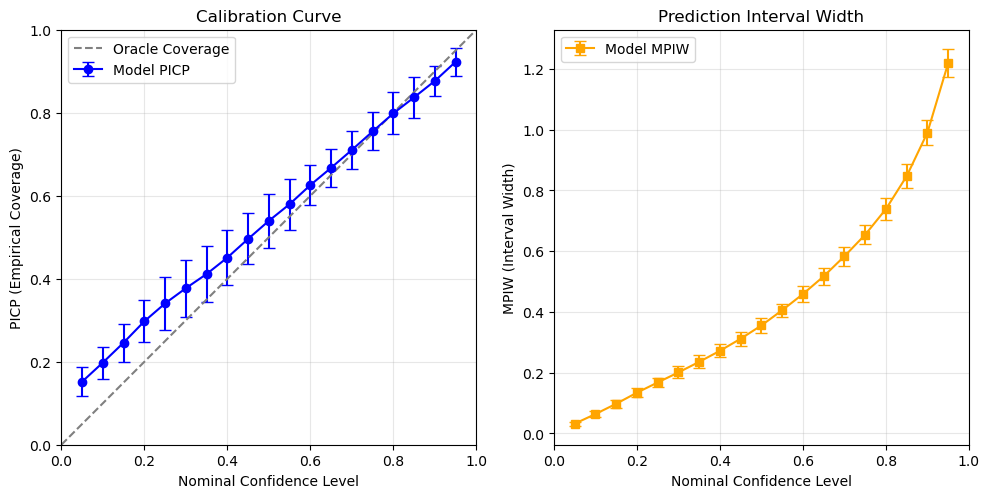

In [95]:
show_result_of_all_runs(out_qrfpp_1)

### max_leaf_nodes = 300

In [96]:
%%time
out_qrfpp_2 = repeat_qrfpp(N_rep=20, max_leaf_nodes=300)

CPU times: total: 40.2 s
Wall time: 21.1 s


- R^2 : 0.896765 ± 0.025836
- CRPS : 0.164561 ± 0.017340
- Confidence levels: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
- PICP (mean):
 [0.08415842 0.13316832 0.18861386 0.22623762 0.27920792 0.32623762
 0.38069307 0.43019802 0.47574257 0.52475248 0.56831683 0.62574257
 0.67475248 0.72029703 0.7529703  0.79009901 0.82722772 0.87029703
 0.92376238]
- PICP (std):
 [0.03422651 0.03697659 0.0434376  0.05060898 0.06682985 0.06827198
 0.06841541 0.06969305 0.06884393 0.06773319 0.06739949 0.06172058
 0.05672801 0.0529379  0.04509844 0.05015416 0.04648987 0.0393432
 0.03359049]
- MPIW (mean):
 [0.03536727 0.07133836 0.10651925 0.14052562 0.17452492 0.20771889
 0.24366228 0.2809743  0.31867198 0.36274219 0.40979616 0.46136755
 0.51352613 0.57326161 0.6407325  0.7217124  0.82030125 0.95464383
 1.17209837]
- MPIW (std):
 [0.0059677  0.01047261 0.01340305 0.01631892 0.01716748 0.01929721
 0.01962428 0.01924191 0.01887031 0.02153749 0.02386153

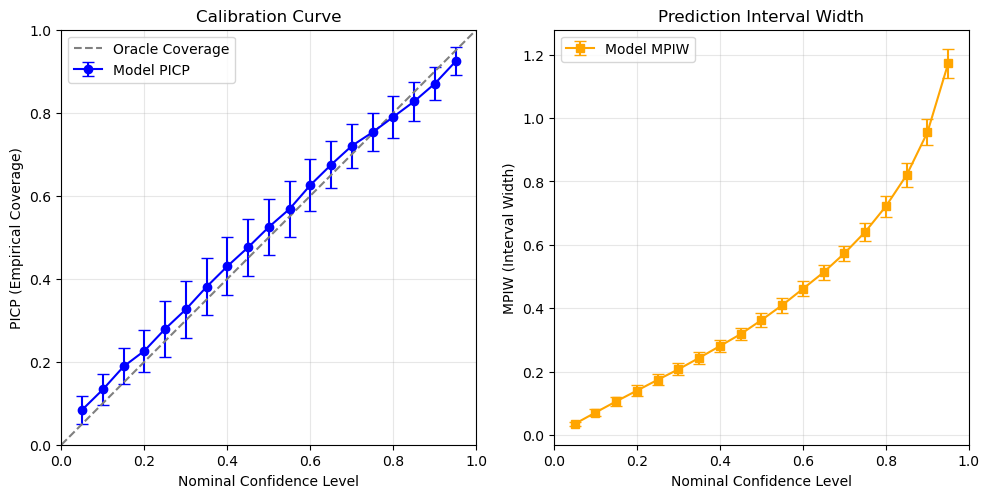

In [97]:
show_result_of_all_runs(out_qrfpp_2)

# Comparison

In [99]:
for name, out in zip(["GP", "QRF", "QRF++_1", "QRF++_2"], [out_gp, out_qrf, out_qrfpp_1, out_qrfpp_2]):
    print(name)
    print(r"- R^2 : {:.6f} ± {:.6f}".format(np.mean(out[0]), np.std(out[0])))
    print(r"- CRPS : {:.6f} ± {:.6f}".format(np.mean(out[1]), np.std(out[1])))

GP
- R^2 : 0.916197 ± 0.027314
- CRPS : 0.145890 ± 0.018238
QRF
- R^2 : 0.900281 ± 0.026732
- CRPS : 0.158365 ± 0.016744
QRF++_1
- R^2 : 0.901374 ± 0.026590
- CRPS : 0.158729 ± 0.017052
QRF++_2
- R^2 : 0.896765 ± 0.025836
- CRPS : 0.164561 ± 0.017340


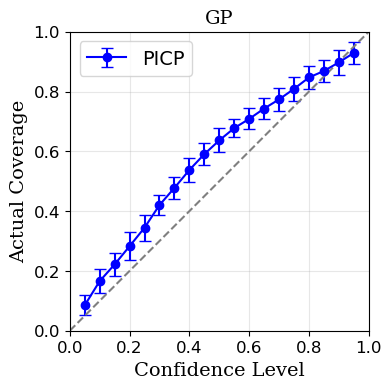

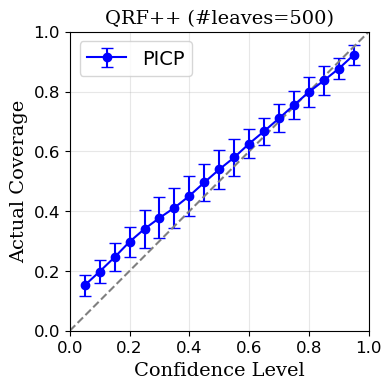

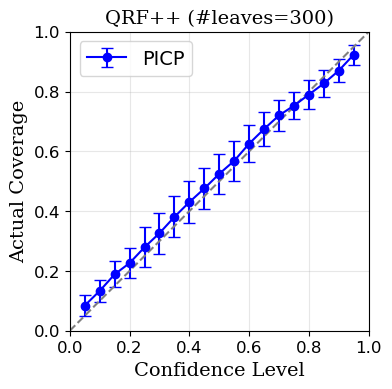

In [ ]:
names = ["GP", "QRF++ (#leaves=500)", "QRF++ (#leaves=300)"]

for m, out in enumerate([out_gp, out_qrfpp_1, out_qrfpp_2]):

    conf = out[2][0]['Nominal_Confidence_Level'].values
    p_mean = np.c_[[table['PICP'].values for table in out[2]]].mean(axis=0)
    p_std = np.c_[[table['PICP'].values for table in out[2]]].std(axis=0)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.errorbar(conf, p_mean, yerr=p_std, fmt='o-', capsize=4, color='blue', label='PICP')
    ax.plot([0, 1], [0, 1], color='grey', linestyle='--')

    ax.set_xlabel('Confidence Level', font='serif', fontsize=14)
    ax.set_ylabel('Actual Coverage', font='serif', fontsize=14)
    ax.set_title(names[m], font='serif', fontsize=14)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend(fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_box_aspect(1)
    fig.tight_layout()
    # fig.savefig("fg_PICP_" + names[m].replace(" ", "_") + ".pdf", dpi=400)

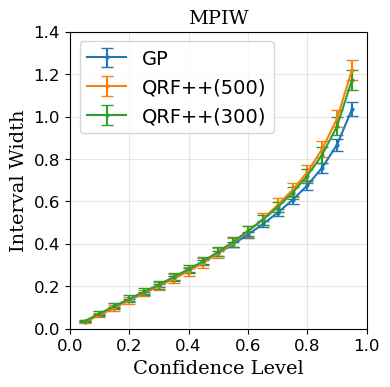

In [ ]:
names = ["GP", "QRF++(500)", "QRF++(300)"]
fig, ax = plt.subplots(figsize=(4, 4))

for m, out in enumerate([out_gp, out_qrfpp_1, out_qrfpp_2]):

    conf = out[2][0]['Nominal_Confidence_Level'].values
    m_mean = np.c_[[table['MPIW'].values for table in out[2]]].mean(axis=0)
    m_std = np.c_[[table['MPIW'].values for table in out[2]]].std(axis=0)

    ax.errorbar(conf, m_mean, yerr=m_std, fmt='o-', capsize=4, markersize=2,
                color=["C0", "C1", "C2"][m], label=names[m])

    ax.set_xlabel('Confidence Level', font='serif', fontsize=14)
    ax.set_ylabel('Interval Width', font='serif', fontsize=14)
    ax.set_title("MPIW", font='serif', fontsize=14)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.4])
    ax.legend(fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_box_aspect(1)
    fig.tight_layout()
    # fig.savefig("fg_MPIW.pdf", dpi=400)